In [2]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [3]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/*.nc"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]

File 0: /Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc
<xarray.Dataset> Size: 438MB
Dimensions:            (station: 9, valid_time: 750192)
Coordinates:
  * station            (station) int64 72B 1 2 3 4 5 6 7 8 10
  * valid_time         (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-07...
    latitude           float64 8B ...
    longitude          float64 8B ...
    station_latitude   (station) float64 72B ...
    station_longitude  (station) float64 72B ...
Data variables: (12/14)
    u10                (station, valid_time) float32 27MB ...
    v10                (station, valid_time) float32 27MB ...
    d2m                (station, valid_time) float32 27MB ...
    t2m                (station, valid_time) float32 27MB ...
    msl                (station, valid_time) float32 27MB ...
    sst                (station, valid_time) float32 27MB ...
    ...                 ...
    mwd                (station, valid_time) float32 27MB ...
    mwp                (station

In [4]:
def preprocess(ds):
    return ds.sortby("station") 

datasets = [preprocess(xr.open_dataset(f)) for f in files]
ds = xr.concat(datasets, dim="station")
ds_sealevel = ds

In [5]:
ds_recent = ds.where(ds["valid_time"].dt.year >= 2000, drop=True)

In [6]:
ds = ds_recent

In [7]:
import xarray as xr
import numpy as np

# keep original untouched
ds["original"] = ds["residual"].astype("float64")

# --- Compute station-wise mean and std ---
mu  = ds["original"].mean(dim="valid_time", skipna=True)
sig = ds["original"].std(dim="valid_time", skipna=True)

# --- Build mask using Z-score ---
z_thresh = 5
z_scores = (ds["original"] - mu) / sig
mask = np.abs(z_scores) < z_thresh   # True = keep, False = set to NaN

# --- Apply Z-score filter ---
resid_filt = ds["original"].where(mask)

# --- Clause: negatives cannot exceed positives in magnitude ---
# compute max positive per station
max_pos = resid_filt.where(resid_filt > 0).max(dim="valid_time", skipna=True)

# build a mask: keep only if residual >= -max_pos
mask_balance = resid_filt >= (-max_pos)

# apply mask (bad negatives -> NaN)
resid_filt2 = resid_filt.where(mask_balance)

# assign back
ds["residual"] = resid_filt2

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [8]:
# Ensure time is sorted (important for derivatives)
ds = ds.sortby("valid_time")

# --- Core helpers (finite differences over hours) ---
def diff_hours(da, hours: int):
    """Finite-difference derivative over 'hours' (value change per hour)."""
    return (da - da.shift(valid_time=hours)) / hours

# --- Wind features ---
u = ds["u10"]
v = ds["v10"]
wind_speed = np.hypot(u, v).rename("wind_speed")

d_wind_1h = diff_hours(wind_speed, 1).rename("d_wind_1h")   # Δwind / 1h
d_wind_6h = diff_hours(wind_speed, 6).rename("d_wind_6h")   # Δwind / 6h

# --- Pressure derivatives (dsp/dt) ---
sp = ds["sp"]
d_sp_1h = diff_hours(sp, 1).rename("d_sp_1h")
d_sp_6h = diff_hours(sp, 6).rename("d_sp_6h")

# --- Tide shifted features ---
tide_lag1h = ds["tide"].shift(valid_time=1).rename("tide_lag1h")
tide_lag6h = ds["tide"].shift(valid_time=6).rename("tide_lag6h")
tide_lag0h = ds["tide"].shift(valid_time=0).rename("tide_lag0h")

# Make sure sorted
ds = ds.sortby("valid_time")

# Pull just tide to a tidy frame
df = ds[["tide"]].to_dataframe().reset_index()
df = df.sort_values(["station", "valid_time"])

# Compute tidal range per station (across all valid_time)
tide_range = (ds["tide"].max(dim="valid_time") - ds["tide"].min(dim="valid_time"))
tide_range = tide_range.rename("tide_range")

# --- Air density (rho_air) ---
# Use sp (Pa) and t2m (K) if available; else fallback to 1.225 kg/m^3
R_d = 287.05  # J kg^-1 K^-1
if "sp" in ds and "t2m" in ds:
    rho_air = (ds["sp"] / (R_d * ds["t2m"])).astype("float32").rename("rho_air")
else:
    rho_air = xr.zeros_like(wind_speed) + 1.225
    rho_air = rho_air.astype("float32").rename("rho_air")

# --- Drag coefficient C_D (Large & Pond style) ---
U = wind_speed
Cd = xr.where(
    U < 11.0,
    1.14e-3,
    xr.where(U <= 25.0, (0.49 + 0.065 * U) * 1e-3, 2.0e-3)
).astype("float32").rename("Cd")

# --- Wind stress components (N/m^2 = Pa) ---
tau_x = (rho_air * Cd * U * u).astype("float32").rename("tau_x")
tau_y = (rho_air * Cd * U * v).astype("float32").rename("tau_y")
tau_mag = (rho_air * Cd * U**2).astype("float32").rename("tau_mag")

# Optional: tendencies (change over 1h/6h), consistent with your diff_hours helper
tau_d1h = diff_hours(tau_mag, 1).astype("float32").rename("d_tau_1h")
tau_d6h = diff_hours(tau_mag, 6).astype("float32").rename("d_tau_6h")

# --- Assemble into one dataset ---
feat_ds = xr.Dataset(
    {
        "wind_speed": wind_speed,
        "d_wind_1h": d_wind_1h,
        "d_wind_6h": d_wind_6h,
        "d_sp_1h": d_sp_1h,
        "d_sp_6h": d_sp_6h,
        "tide_range_12h": tide_range,
        "tide_lag0h": tide_lag0h,
        "tide_lag1h": tide_lag1h,
        "tide_lag6h": tide_lag6h,
        # "d_msl_1h": d_msl_1h,  # uncomment if you computed these
        # "d_msl_6h": d_msl_6h,
        "tau_x": tau_x,
        "tau_y": tau_y,
        "tau_mag": tau_mag,
        "tau_d1h": tau_d1h,
        "tau_d6h": tau_d6h,
    }
)

# Keep original coordinates/attrs
feat_ds = feat_ds.assign_coords(
    station=ds["station"],
    valid_time=ds["valid_time"]
)
for v in feat_ds.data_vars:
    feat_ds[v].attrs.update(ds[v.split("_")[0]].attrs if v.split("_")[0] in ds.data_vars else {})

# Merge features back with original dataset (optional)
ds_engineered = xr.merge([ds, feat_ds])

In [9]:
ds_engineered = ds_engineered.where(ds["valid_time"].dt.year >= 2000, drop=True)

In [10]:
# exclude target + sea_level + tide from predictors
predictors = [v for v in ds_engineered.data_vars if v not in ["residual", "sea_level", "tide", "longitude", "latitude", "station_longitude", "station_latitude", "station", "valid_time"]]
target = "residual"
features_df = ds_engineered[predictors + [target]].to_dataframe().reset_index()
features_df = features_df.dropna(subset=[target])

# ADd bathymetry_stats

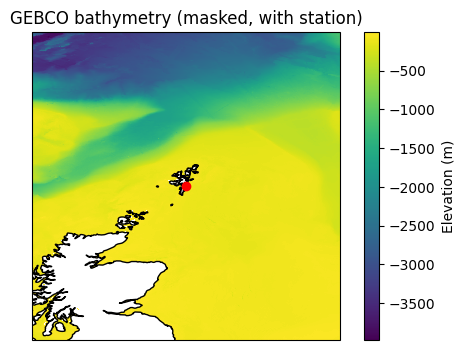

In [11]:
# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

# extract station ids and their lat/lon
stations = ds_sealevel['station'].values
lats = ds_sealevel['station_latitude'].values
lons = ds_sealevel['station_longitude'].values
station = ds_sealevel['station'].values

# build mapping from (lat, lon) to station index
latlon_to_station = {
    (float(lat), float(lon)): int(stn)
    for stn, lat, lon in zip(stations, lats, lons)
}

# if you want unique lat/lon pairs:
unique_latlon = list(latlon_to_station.keys())

# Function to extract square around a lat/lon
def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat + half, lat - half),  # GEBCO lat usually descending
        lon=slice(lon - half, lon + half),
        method="nearest"
    )

results = {
    "0.1x0.1": [],
    "0.25x0.25": [],
    "1x1": [],
    "3x3": [],
    "10x10":[]
}
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    return ds_tile.assign(elevation=ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5))

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg):
    """Fast spatial slice using coordinate indices."""
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat - half, lat + half),
        lon=slice(lon - half, lon + half)
    )

# --- Prep: ensure coordinates are monotonic so .sel(slice) is efficient ---
GEBCO_ds = GEBCO_ds.sortby(["lat", "lon"])

# Available resolutions (keep all for each point)
resolutions = [0.1, 0.25, 1.0, 3.0, 10.0]

# Initialize results dict
results = {f"{r}x{r}": [] for r in resolutions}
#results = {r: [] for r in resolutions}

# Build tiles for every (lat, lon) at every resolution
for lat, lon in unique_latlon:
    for size in resolutions:
        key = f"{size}x{size}"
        results[key].append(extract_square(GEBCO_ds, lat, lon, size))

plot_tile(results["10.0x10.0"][0])

In [12]:
import numpy as np
import xarray as xr

def to_128x128(ds_tile: xr.Dataset, H: int = 128, W: int = 128) -> xr.Dataset:
    """
    Quick, vectorized resize of a GEBCO tile to (H,W) using xarray's interp.
    Works for all numeric vars defined on (lat, lon). Keeps dask laziness.
    """
    # Build uniform target coords spanning the tile extent (ascending)
    lat0, lat1 = float(ds_tile.lat.min()), float(ds_tile.lat.max())
    lon0, lon1 = float(ds_tile.lon.min()), float(ds_tile.lon.max())
    new_lat = np.linspace(lat0, lat1, H, dtype=np.float32)
    new_lon = np.linspace(lon0, lon1, W, dtype=np.float32)

    # Interpolate all variables defined on (lat, lon)
    return ds_tile.interp(lat=new_lat, lon=new_lon, method="linear")

# --- apply to every tile in your dict ---
results_128 = {k: [to_128x128(ds) for ds in tiles] for k, tiles in results.items()}

# sanity check (first available tile per bucket should be 128x128)
for k, tiles in results_128.items():
    if tiles:
        shp = tiles[0]["elevation"].shape
        assert shp == (128, 128), f"{k} -> {shp}, expected (128, 128)"

del GEBCO_ds

In [13]:
rows = []
for i, (lat, lon) in enumerate(unique_latlon):
    row = {"latitude": lat, "longitude": lon}
    for size in resolutions:
        key = f"{size}x{size}"
        xr_tile = results_128[key][i]
        elev = xr_tile["elevation"].where(xr_tile["elevation"] <= -0.5)
        row[f"tile_{size}"] = elev.values  # 2D array
        # save plotting extent = [lon_min, lon_max, lat_min, lat_max]
        row[f"extent_{size}"] = [
            float(xr_tile["lon"].min()), float(xr_tile["lon"].max()),
            float(xr_tile["lat"].min()), float(xr_tile["lat"].max())
        ]
    rows.append(row)

df = pd.DataFrame(rows)

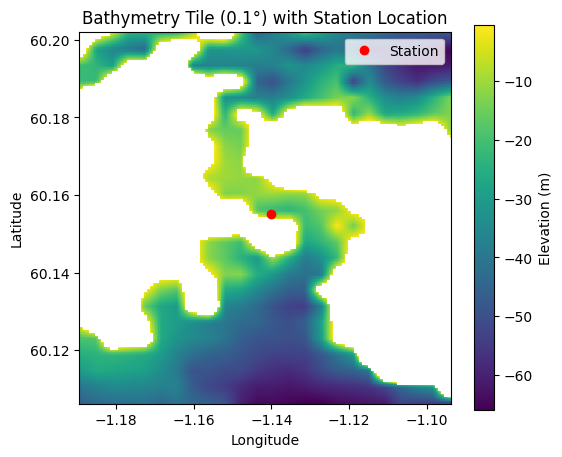

In [14]:

# Select the first row
tile = df["tile_0.1"][0]
lon_min, lon_max, lat_min, lat_max = df["extent_0.1"][0]

station_lon = df["longitude"][0]
station_lat = df["latitude"][0]

plt.figure(figsize=(6, 5))
im = plt.imshow(
    tile,
    extent=[lon_min, lon_max, lat_min, lat_max],
    origin="lower" if lat_min < lat_max else "upper",
    aspect="equal"
)

# Plot the station coordinate
plt.plot(station_lon, station_lat, 'ro', markersize=6, label='Station')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Bathymetry Tile (0.1°) with Station Location")
plt.colorbar(im, label="Elevation (m)")
plt.legend()
plt.show()


In [15]:
import numpy as np

def _station_pixel_indices(st_lat, st_lon, extent, ny, nx):
    lon_min, lon_max, lat_min, lat_max = extent
    dlon = (lon_max - lon_min) / (nx - 1)
    dlat = (lat_max - lat_min) / (ny - 1)

    if lat_max >= lat_min:  # ascending latitude
        iy = int(round((st_lat - lat_min) / dlat))
    else:                   # descending latitude
        dlat = (lat_min - lat_max) / (ny - 1)
        iy = int(round((lat_min - st_lat) / dlat))

    ix = int(round((st_lon - lon_min) / dlon))
    iy = np.clip(iy, 0, ny - 1)
    ix = np.clip(ix, 0, nx - 1)
    return iy, ix, dlat, dlon

def _meters_per_degree(lat_deg):
    lat_rad = np.deg2rad(lat_deg)
    return 111_132.0, 111_320.0 * np.cos(lat_rad)

def tile_stats_near_station(tile, extent, st_lat, st_lon, radius_cells=3):
    """
    Stats in a (2r+1)^2 window near station:
      - slope (deg)   [mean of gradient magnitude in deg]
      - roughness std (m)
      - relief p2p (m)
      - mean bathymetry (m) over ocean-only cells (<= -0.5 m)
    """
    if tile is None or np.all(np.isnan(tile)):
        return np.nan, np.nan, np.nan, np.nan

    ny, nx = tile.shape
    iy, ix, dlat_deg, dlon_deg = _station_pixel_indices(st_lat, st_lon, extent, ny, nx)

    y0 = max(0, iy - radius_cells); y1 = min(ny, iy + radius_cells + 1)
    x0 = max(0, ix - radius_cells); x1 = min(nx, ix + radius_cells + 1)

    sub = tile[y0:y1, x0:x1]
    if sub.size == 0 or np.all(np.isnan(sub)):
        return np.nan, np.nan, np.nan, np.nan

    # Ocean-only mask for mean bathy
    sub_ocean = np.where(sub <= -0.5, sub, np.nan)
    mean_bathy = float(np.nanmean(sub_ocean))

    # Pixel spacings (meters) at station latitude
    m_per_deg_lat, m_per_deg_lon = _meters_per_degree(st_lat)
    dy_m = dlat_deg * m_per_deg_lat
    dx_m = dlon_deg * m_per_deg_lon

    # Gradients (fill small NaN gaps just for gradient)
    sub_filled = np.where(np.isnan(sub), np.nanmean(sub), sub) if np.isnan(sub).any() else sub
    gy, gx = np.gradient(sub_filled, dy_m, dx_m)
    slope_mag = np.sqrt(gx**2 + gy**2)           # rise/run
    slope_deg = np.degrees(np.arctan(slope_mag)) # to degrees
    slope_deg = np.where(np.isnan(sub), np.nan, slope_deg)

    slope_local = float(np.nanmean(slope_deg))
    roughness_std = float(np.nanstd(sub))
    relief_p2p = float(np.nanmax(sub) - np.nanmin(sub))

    return slope_local, roughness_std, relief_p2p, mean_bathy

# ---- Apply to all resolutions and add columns ----
radius_cells = 3  # e.g., 7x7 window; tweak as needed

for size in resolutions:  # [0.1, 0.25, 1.0, 3.0, 10.0]
    key = f"{size}"
    tile_col   = f"tile_{key}"
    extent_col = f"extent_{key}"

    df[f"slope_deg_{key}"]      = np.nan
    df[f"roughness_std_{key}"]  = np.nan
    df[f"relief_p2p_{key}"]     = np.nan
    df[f"mean_bathy_{key}"]     = np.nan

    for idx in range(len(df)):
        tile = df.at[idx, tile_col]
        extent = df.at[idx, extent_col]
        st_lat = df.at[idx, "latitude"]
        st_lon = df.at[idx, "longitude"]

        s, rstd, rpp, mb = tile_stats_near_station(tile, extent, st_lat, st_lon, radius_cells)
        df.at[idx, f"slope_deg_{key}"]     = s
        df.at[idx, f"roughness_std_{key}"] = rstd
        df.at[idx, f"relief_p2p_{key}"]    = rpp
        df.at[idx, f"mean_bathy_{key}"]    = mb

# Quick peek
print(df.filter(regex=r'^(latitude|longitude|slope_deg_|roughness_std_|relief_p2p_|mean_bathy_)').head())

    latitude  longitude  slope_deg_0.1  roughness_std_0.1  relief_p2p_0.1  \
0  60.155000  -1.140000       2.556153           6.277268       19.727524   
1  61.933000   5.117000       2.249864           3.230781       13.222487   
2  60.154028  -1.140306       3.673631           6.227968       19.388529   
3  60.398046   5.320487       1.550942           2.775370       13.349433   
4  61.933776   5.113310       4.493801           5.673448       16.349896   

   mean_bathy_0.1  slope_deg_0.25  roughness_std_0.25  relief_p2p_0.25  \
0      -14.426290        1.584700            4.874393        19.935015   
1      -19.319174        3.230164           10.342867        52.423476   
2      -11.714256        1.895360            5.546549        19.935015   
3       -8.448963        2.136683            8.918766        36.261825   
4      -11.276415        2.492696            6.556816        23.910919   

   mean_bathy_0.25  ...  relief_p2p_1.0  mean_bathy_1.0  slope_deg_3.0  \
0       -12.564777

In [16]:
features_df = (
    features_df
    .drop(columns=["latitude", "longitude"])
    .rename(columns={
        "station_latitude": "latitude",
        "station_longitude": "longitude"
    })
)

In [17]:
df["latitude"]  = df["latitude"].round(2)
df["longitude"] = df["longitude"].round(2)
features_df["latitude"]  = features_df["latitude"].round(2)
features_df["longitude"] = features_df["longitude"].round(2)

summary_cols = [
    'latitude', 'longitude',
    'slope_deg_0.1','roughness_std_0.1','relief_p2p_0.1','mean_bathy_0.1',
    'slope_deg_0.25','roughness_std_0.25','relief_p2p_0.25','mean_bathy_0.25',
    'slope_deg_1.0','roughness_std_1.0','relief_p2p_1.0','mean_bathy_1.0',
    'slope_deg_3.0','roughness_std_3.0','relief_p2p_3.0','mean_bathy_3.0',
    'slope_deg_10.0','roughness_std_10.0','relief_p2p_10.0','mean_bathy_10.0'
]

summary_df = df[summary_cols]

In [18]:
merged = summary_df.merge(features_df, on=["latitude", "longitude"], how="inner")

# Train on full

In [23]:
# drop NaNs
merged = merged .dropna(subset=["residual"])

In [24]:
RANDOM_SEED=42
# 2) Random 10% sample
sample_frac = 0.1
merged = merged.sample(frac=sample_frac, random_state=RANDOM_SEED)

In [25]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
RANDOM_SEED=42

In [31]:
def stats(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100.0
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_%": mape}

rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted( merged["station"].unique()))
perm = rng.permutation(stations)

predictors = [
    col for col in merged.columns
    if col not in ["latitude", "longitude", "valid_time", "residual", "station", "original"]
]

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.10 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = merged["station"].isin(train_stn)
m_val   = merged["station"].isin(val_stn)
m_test  = merged["station"].isin(test_stn)

X_cols = predictors  # all other variables as predictors

X_train, y_train =  merged.loc[m_train, X_cols],  merged.loc[m_train, target]
X_val,   y_val   =  merged.loc[m_val,   X_cols],  merged.loc[m_val,   target]
X_test,  y_test  =  merged.loc[m_test,  X_cols],  merged.loc[m_test,  target]

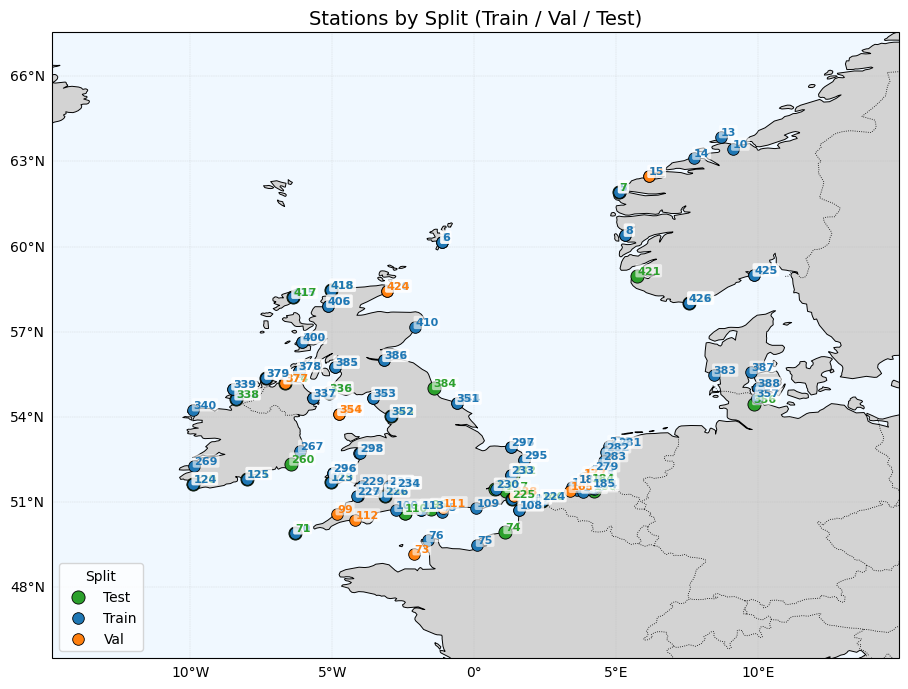

Saved: station_split_map.png


In [32]:
# pip install cartopy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1) Unique stations with coordinates
st_meta = (
    merged[["station", "latitude", "longitude"]]
    .dropna(subset=["latitude", "longitude"])
    .drop_duplicates(subset=["station"])
    .sort_values("station")
    .reset_index(drop=True)
)

# 2) Add split label
def split_label(s):
    if s in train_stn: return "train"
    if s in val_stn:   return "val"
    if s in test_stn:  return "test"
    return "unknown"

st_meta["split"] = st_meta["station"].apply(split_label)

# 3) Map setup
lon_min, lon_max = st_meta["longitude"].min(), st_meta["longitude"].max()
lat_min, lat_max = st_meta["latitude"].min(),  st_meta["latitude"].max()

# pad the extent a bit
d_lon = (lon_max - lon_min) or 1.0
d_lat = (lat_max - lat_min) or 1.0
pad = 0.25
extent = [lon_min - pad*d_lon, lon_max + pad*d_lon,
          lat_min - pad*d_lat, lat_max + pad*d_lat]

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=proj)
ax.set_extent(extent, crs=proj)

# basemap features
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--")
gl.right_labels = False
gl.top_labels = False

# 4) Plot by split
colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green", "unknown": "gray"}
sizes  = {"train": 70, "val": 70, "test": 90, "unknown": 60}  # make test a bit bigger

for split, df_split in st_meta.groupby("split"):
    ax.scatter(
        df_split["longitude"], df_split["latitude"],
        s=sizes.get(split, 70),
        color=colors.get(split, "gray"),
        edgecolor="k",
        linewidth=0.6,
        transform=proj,
        zorder=5,
        label=split.capitalize()
    )

# 5) Optional: label station IDs
label_points = True
if label_points:
    for _, r in st_meta.iterrows():
        ax.text(
            r["longitude"], r["latitude"],
            f'{int(r["station"])}',
            transform=proj,
            fontsize=8, weight="bold",
            ha="left", va="bottom",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6),
            zorder=6,
            color=colors.get(r["split"], "black")
        )

# legend & title
handles, labels = ax.get_legend_handles_labels()
# deduplicate legend entries
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc="lower left", title="Split")
plt.title("Stations by Split (Train / Val / Test)", fontsize=14)
plt.tight_layout()
plt.savefig("station_split_map.png", dpi=150)
plt.show()

print("Saved: station_split_map.png")

In [33]:
# ---------------------------
# 4) XGBoost model
# ---------------------------
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ---------------------------
# 4) XGBoost model (emphasize extremes via sample_weight)
# ---------------------------
thr = np.quantile(y_train, 0.95)
w = np.ones_like(y_train, float)
w[y_train >= thr] = 3.0  # try 2–5 first, not 10–50

model = XGBRegressor(
    n_estimators=800,           # a bit more estimators with low LR
    learning_rate=0.015,
    max_depth=6,               # shallower to reduce overfit in tail
    min_child_weight=10,       # stronger regularization
    subsample=0.8,
    colsample_bytree=0.6,
    reg_lambda=10.0,
    gamma=1.0,                 # discourage tiny splits
    tree_method="hist",
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

model.fit(X_train, y_train, sample_weight=w, eval_set=[(X_val, y_val)], verbose=False)

# ---------------------------
# 5) Evaluate
# ---------------------------
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance:")
_ = evaluate("Train", X_train, y_train, model)
_ = evaluate(" Val ", X_val,   y_val,   model)
test_pred = evaluate("Test ", X_test,  y_test,  model)

# ---------------------------
# 6) Save model + test predictions
# ---------------------------
#joblib.dump({"model": model, "features": X_cols}, "xgb_residual_model.joblib")
out = merged.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: xgb_residual_model.joblib")
print("Saved: test_predictions.parquet")

Performance:
Train | R2: 0.3071 | MAE: 0.1180
 Val  | R2: 0.4598 | MAE: 0.1022
Test  | R2: 0.1427 | MAE: 0.1253
Saved: xgb_residual_model.joblib
Saved: test_predictions.parquet


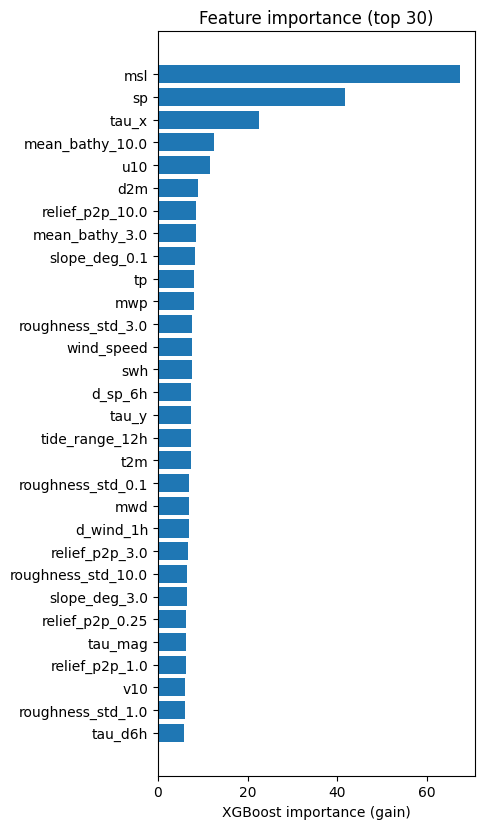

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Choose which importance definition you want: 'gain', 'weight', 'cover', 'total_gain', 'total_cover'
importance_type = 'gain'

# Grab importance from booster with your feature names
booster = model.get_booster()
# X_cols should be a list-like of your training column names (order must match X_train)
booster.feature_names = list(map(str, X_cols))

score_dict = booster.get_score(importance_type=importance_type)
# Ensure all features appear (fill missing with 0)
imp = np.array([score_dict.get(str(f), 0.0) for f in X_cols], dtype=float)

order = np.argsort(imp)[::-1]
top_k = 30  # show top-N
order = order[:top_k]

plt.figure(figsize=(5, max(2, 0.28*len(order))))
plt.barh(np.array(X_cols)[order][::-1], imp[order][::-1])
plt.xlabel(f"XGBoost importance ({importance_type})")
plt.title("Feature importance (top {})".format(len(order)))
plt.tight_layout()
plt.show()


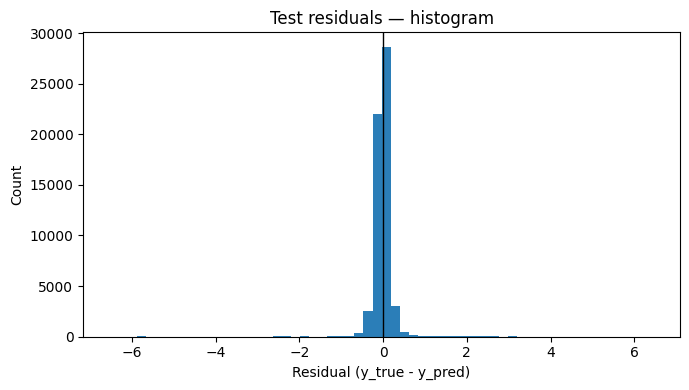

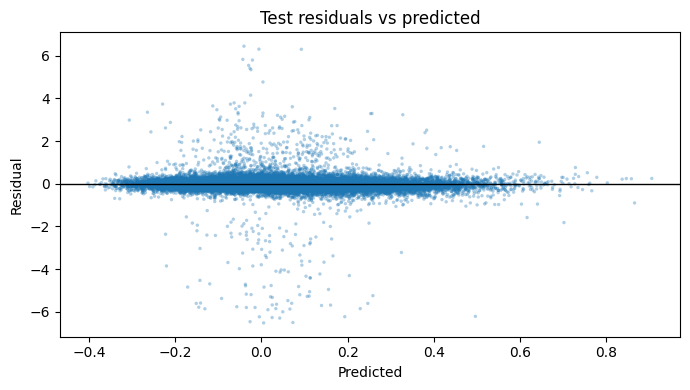

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# If starting fresh, load what you saved:
# out = pd.read_parquet("test_predictions.parquet")

# Make sure the columns are named consistently
preds = out.rename(columns={"residual_pred": "y_pred", target: "y_true"}).copy()
preds["valid_time"] = pd.to_datetime(preds["valid_time"])
preds["residual"] = preds["y_true"] - preds["y_pred"]

# --- A) Residual histogram ---
plt.figure(figsize=(7,4))
plt.hist(preds["residual"].dropna(), bins=60, alpha=0.95)
plt.axvline(0, color="k", lw=1)
plt.xlabel("Residual (y_true - y_pred)")
plt.ylabel("Count")
plt.title("Test residuals — histogram")
plt.tight_layout()
plt.show()

# --- B) Residuals vs Predicted (heteroscedasticity check) ---
plt.figure(figsize=(7,4))
plt.scatter(preds["y_pred"], preds["residual"], s=6, alpha=0.35, edgecolors="none")
plt.axhline(0, color="k", lw=1)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Test residuals vs predicted")
plt.tight_layout()
plt.show()


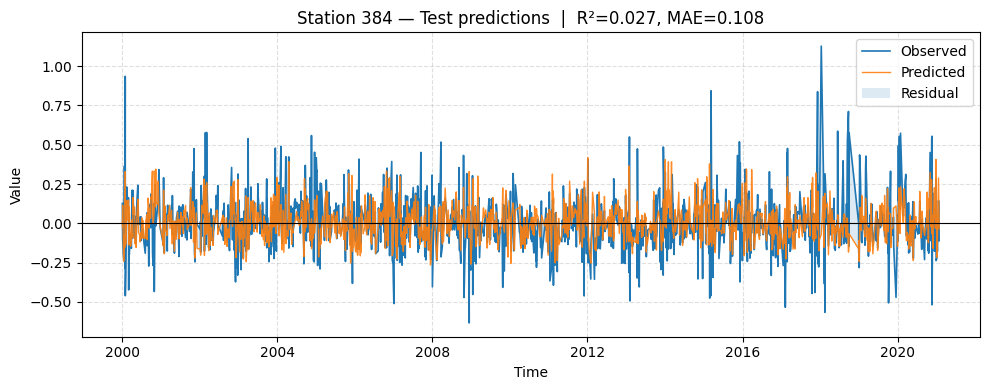

In [36]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id):
    g = preds[preds["station"] == station_id].sort_values("valid_time")
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.axhline(0, color="k", lw=0.8)
    plt.title(f"Station {station_id} — Test predictions  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value"); plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example:
plot_station_residuals(preds['station'].iloc[0])


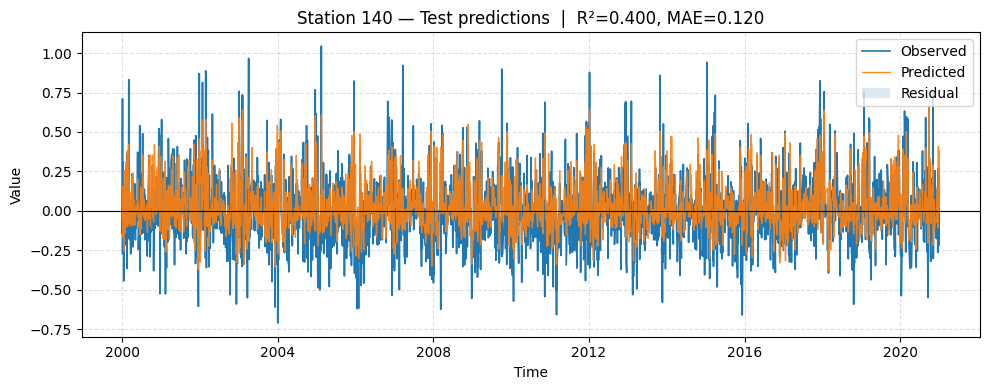

In [37]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id):
    g = preds[preds["station"] == station_id].sort_values("valid_time")
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.axhline(0, color="k", lw=0.8)
    plt.title(f"Station {station_id} — Test predictions  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value"); plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example:
plot_station_residuals(preds['station'].iloc[32])

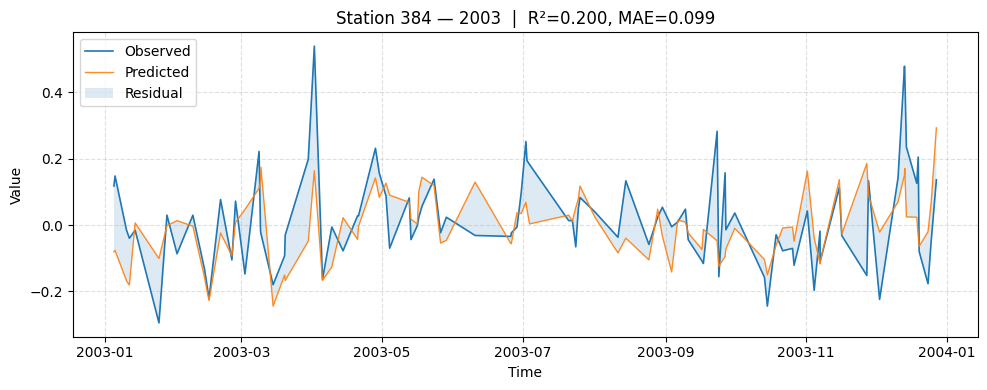

In [38]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id, year=None):
    g = preds[preds["station"] == station_id].sort_values("valid_time").copy()
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    
    if year is not None:
        g = g[g["valid_time"].dt.year == year]
        if g.empty:
            print(f"No test rows for station {station_id} in year {year}")
            return
    
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.title(f"Station {station_id} — {year if year else 'Full period'}  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value")
    plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example: first station in 2017
plot_station_residuals(preds['station'].iloc[0], year=2003)


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_50364/4089206154.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: r2_score(g["y_true"], g["y_pred"]) if len(g) > 1 else np.nan)


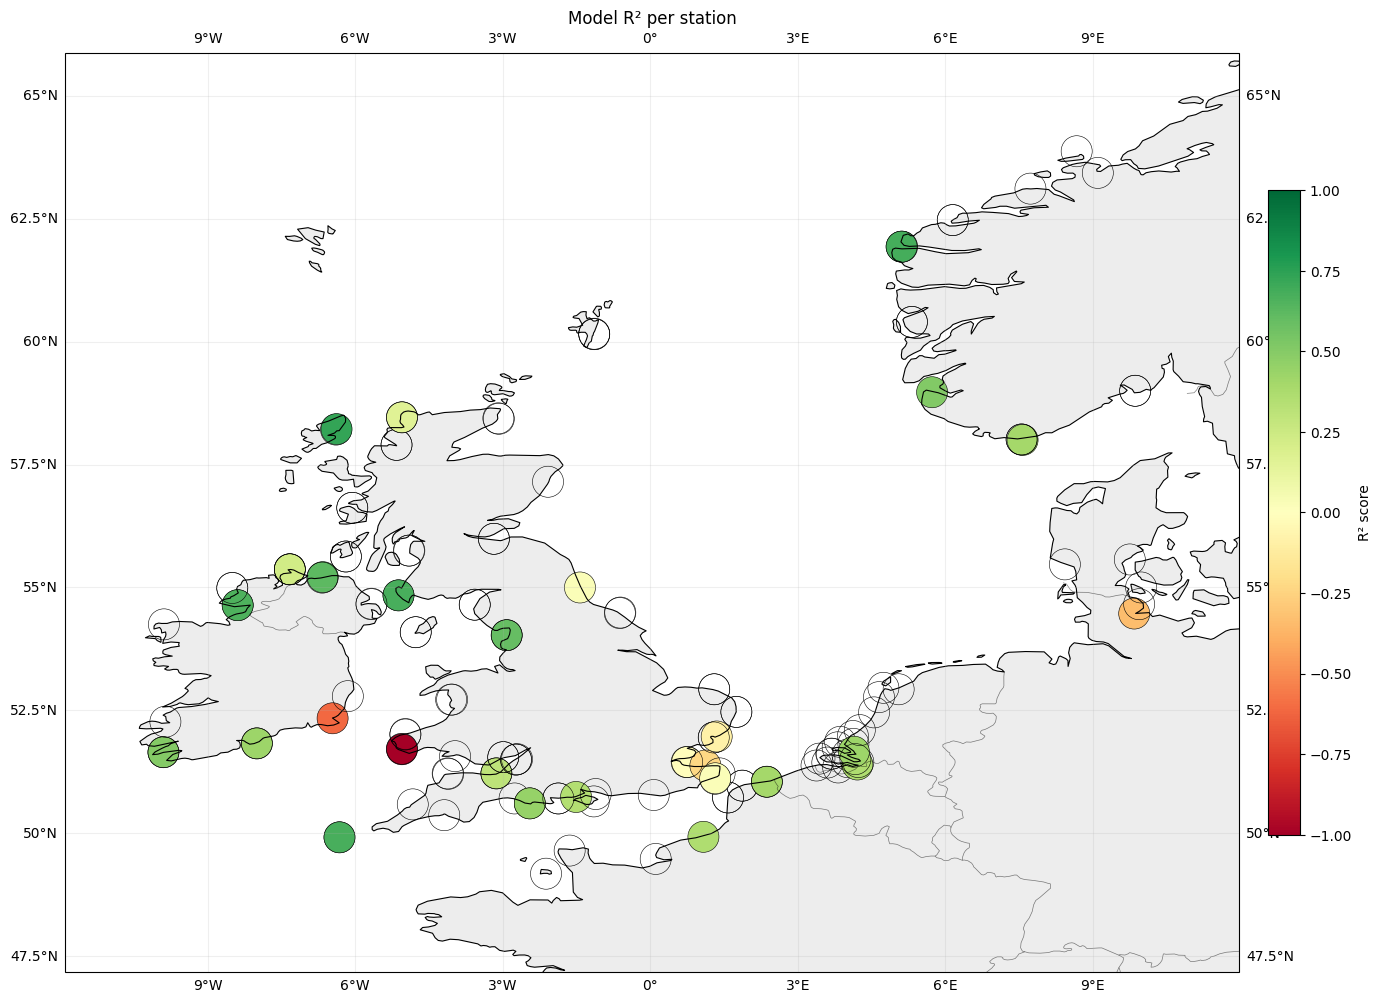

In [39]:
from sklearn.metrics import r2_score

# Compute R² per station
station_r2 = (
    preds.groupby("station")
         .apply(lambda g: r2_score(g["y_true"], g["y_pred"]) if len(g) > 1 else np.nan)
         .rename("r2")
         .reset_index()
         .sort_values("r2")
)

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Get unique station coordinates ---
station_coords = merged.groupby("station")[["latitude","longitude"]].first().reset_index()

# --- Join R² scores ---
station_scores = station_coords.merge(station_r2, on="station", how="left")

# --- Plot ---
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Base map
ax.set_extent([
    station_scores["longitude"].min() - 2,
    station_scores["longitude"].max() + 2,
    station_scores["latitude"].min() - 2,
    station_scores["latitude"].max() + 2
])
ax.coastlines(resolution="50m", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.4)
ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, alpha=0.2)

# Scatter stations colored by R²
sc = ax.scatter(
    station_scores["longitude"],
    station_scores["latitude"],
    c=station_scores["r2"],
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    s=500,
    edgecolor="k",
    linewidth=0.4,
    transform=ccrs.PlateCarree()
)

# Colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("R² score")

plt.title("Model R² per station")
plt.tight_layout()
plt.show()
